# Modelo de taxas variáveis — mistura Poisson–Gama

Em A7–A10, a variável Gama é a **intensidade agregada do setor** $x_k$, não uma PD Gama independente por contraparte. Condicionalmente a $x_k$, cada PD individual varia proporcionalmente ao fator comum; isso gera dependência entre contrapartes do mesmo setor.

## Parâmetros e PGF

$$\mu_k=\sum_A\theta_{Ak}\frac{\varepsilon_A}{\nu_A},\qquad \sigma_k=\sum_A\theta_{Ak}s_A\frac{L_A/L}{\nu_A}.$$

Para $x_k\sim\Gamma(\alpha_k,\beta_k)$,

$$\alpha_k=\mu_k^2/\sigma_k^2,\quad\beta_k=\sigma_k^2/\mu_k,\quad p_k=\beta_k/(1+\beta_k).$$

Com $P_k(z)=\mu_k^{-1}\sum_A\theta_{Ak}(\varepsilon_A/\nu_A)z^{\nu_A}$,

$$G_k(z)=\left(\frac{1-p_k}{1-p_kP_k(z)}\right)^{\alpha_k}.$$

A contagem setorial é NB; a perda setorial é uma NB composta com severidades e a soma de setores distintos não é, em geral, uma única NB.

In [1]:
# Compara o mesmo portfólio sob sigma=0 e sob a volatilidade do XLS.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import (
    analytic_loss_moments, calculate_loss_distribution_detailed
)

portfolio = data.create_example_1a_portfolio()
common = dict(exposures=portfolio.exposure, mean_default_rates=portfolio.mean_default_rate,
              recovery_rates=np.zeros(len(portfolio)), max_loss_dollars=250_000_000)
fixed = calculate_loss_distribution_detailed(std_default_rates=np.zeros(len(portfolio)), **common)
variable = calculate_loss_distribution_detailed(std_default_rates=portfolio.std_default_rate, **common)
fixed_moments = analytic_loss_moments(portfolio.exposure, portfolio.mean_default_rate,
                                      np.zeros(len(portfolio)), np.zeros(len(portfolio)),
                                      unit_size=fixed.unit_size)
variable_moments = analytic_loss_moments(portfolio.exposure, portfolio.mean_default_rate,
                                         portfolio.std_default_rate, np.zeros(len(portfolio)),
                                         unit_size=variable.unit_size)

In [2]:
# Os parâmetros exibidos têm unidade de número de defaults, não de perda monetária.
params = pd.DataFrame({
    'Modelo': ['Fixo', 'Variável'],
    'mu': [fixed.sector_parameters[0].mean_defaults, variable.sector_parameters[0].mean_defaults],
    'sigma_fator': [fixed.sector_parameters[0].std_defaults, variable.sector_parameters[0].std_defaults],
    'alpha': [fixed.sector_parameters[0].alpha, variable.sector_parameters[0].alpha],
    'beta': [fixed.sector_parameters[0].beta, variable.sector_parameters[0].beta],
})
display(params)
assert abs(fixed.expected_loss-variable.expected_loss) < 1e-8
assert variable_moments[1] > fixed_moments[1]
assert max(fixed.tail_mass_upper_bound, variable.tail_mass_upper_bound) < 1e-10

,Modelo,mu,sigma_fator,alpha,beta
0,Fixo,3.134362,0.000000,inf,0.00000
1,Variável,3.134362,1.567181,4.0,0.78359


,Confiança,Fixo,Variável,Diferença
0,0.500,12143340.0,11131395.0,-1011945.0
1,0.750,19834122.0,20643678.0,809556.0
2,0.900,28536849.0,31572684.0,3035835.0
3,0.950,34406130.0,39061077.0,4654947.0
4,0.990,46549470.0,55454586.0,8905116.0
5,0.995,51406806.0,62133423.0,10726617.0
6,0.999,62133423.0,77312598.0,15179175.0


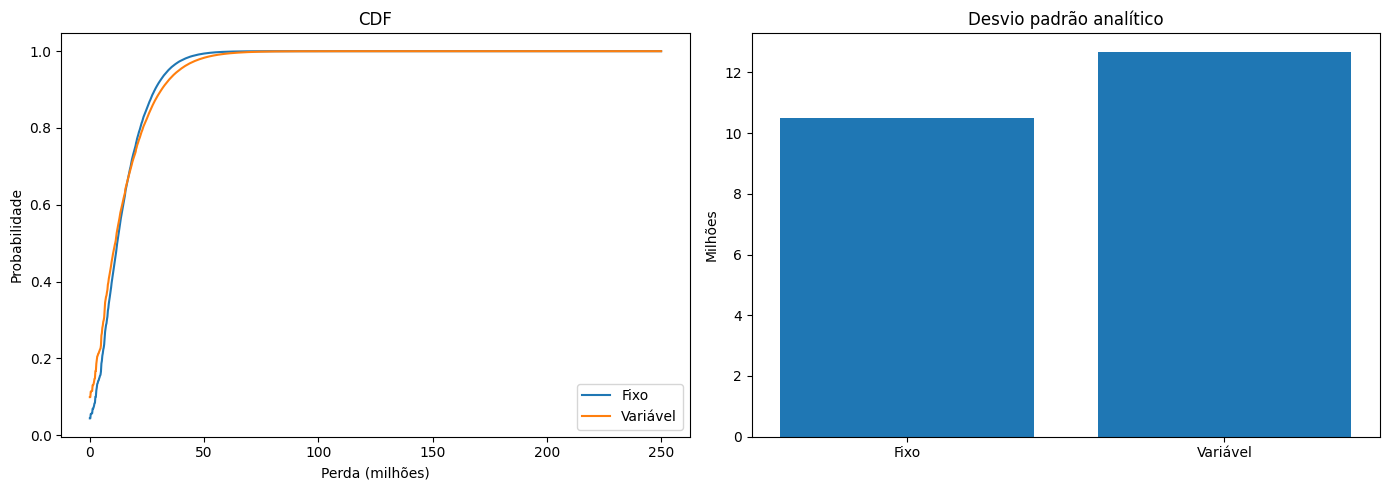

In [3]:
# Comparação de quantis discretos e momentos.
levels = [.50, .75, .90, .95, .99, .995, .999]
comparison = pd.DataFrame({
    'Confiança': levels, 'Fixo': [fixed.quantile(q) for q in levels],
    'Variável': [variable.quantile(q) for q in levels],
})
comparison['Diferença'] = comparison.Variável-comparison.Fixo
display(comparison)

loss_fixed = np.arange(len(fixed.pmf))*fixed.unit_size
loss_variable = np.arange(len(variable.pmf))*variable.unit_size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(loss_fixed/1e6, fixed.cdf, label='Fixo')
axes[0].plot(loss_variable/1e6, variable.cdf, label='Variável')
axes[0].set(title='CDF', xlabel='Perda (milhões)', ylabel='Probabilidade'); axes[0].legend()
axes[1].bar(['Fixo','Variável'], [np.sqrt(fixed_moments[1])/1e6, np.sqrt(variable_moments[1])/1e6])
axes[1].set(title='Desvio padrão analítico', ylabel='Milhões')
plt.tight_layout(); plt.show()

A mistura aumenta a variância para os mesmos inputs médios e, neste exemplo, eleva os quantis altos. Isso não implica ordenação de todos os quantis: a distribuição mais dispersa pode ter mediana menor. A volatilidade não deve ser escolhida por “conservadorismo”, mas estimada e validada no horizonte e segmentação aplicáveis.